In [1]:
from google.colab import drive
import gspread
import pandas as pd
from google.colab import auth
from google.auth import default
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
import re
from collections import defaultdict
import matplotlib.patches as patches
import tifffile as tiff

In [3]:
def load_data(sheet_url, tab_name, tini_amp_values, tend_amp_values, tend_values):
    # Authenticate and create the client
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # Open the worksheet by URL and get the specific tab by name
    sh = gc.open_by_url(sheet_url)
    worksheet = sh.worksheet(tab_name)  # Ensure tab name is correct

    # Get all the data from the sheet
    data = worksheet.get_all_values()

    # Convert to DataFrame
    headers = data[0]  # Assumes the first row is headers
    df = pd.DataFrame(data[1:], columns=headers)

    # Assuming there is a 'Replicate' column with values 'EXP1', 'EXP2', 'EXP3'
    # Create a mapping of replicate type to tini_amp, tend_amp, and tend values
    replicate_map = {
        'exp1': (tini_amp_values[0], tend_amp_values[0], tend_values[0]),
        'exp2': (tini_amp_values[1], tend_amp_values[1], tend_values[1])
    }

    # Add new columns 'tini_amp', 'tend_amp', and 'tend' based on the replicate type
    df['tini_amp'] = df['Replicate'].apply(lambda x: replicate_map[x.lower()][0] if x.lower() in replicate_map else None)
    df['tend_amp'] = df['Replicate'].apply(lambda x: replicate_map[x.lower()][1] if x.lower() in replicate_map else None)
    df['tend'] = df['Replicate'].apply(lambda x: replicate_map[x.lower()][2] if x.lower() in replicate_map else None)

    # Return the dataframe
    return df


expeID='vip_Amp'

tab_name = "vip_Amp_traps"  # Replace with the actual tab name
x2frame = 22
frames2min=10
pixel2um=22


cmap = plt.get_cmap("viridis")  # Use the viridis colormap

# tini_amp and tend_amp values, as well as the final tend values for exp_1, exp_2, exp_3
tini_amp_values = [36, 42]     # Corresponding to exp_1, exp_2
tend_amp_values = [53, 59]    # Corresponding to exp_1, exp_2
tend_values = [126, 107]     # Corresponding to exp_1, exp_2, exp_3

# Load the data with the new columns
df = load_data(sheet_url, tab_name, tini_amp_values, tend_amp_values, tend_values)
print(df)


    Index Experiment Replicate Position   Trap CellType  Status  tini_amp  \
0       1    vip_Amp      EXP1     xy28  trap1      CFP  Killed        36   
1       2    vip_Amp      EXP1     xy08  trap5      VIP  Killed        36   
2       3    vip_Amp      EXP1     xy18  trap1      CFP  Killed        36   
3       4    vip_Amp      EXP1     xy01  trap1      VIP   Alive        36   
4       5    vip_Amp      EXP1     xy18  trap2      VIP   Alive        36   
..    ...        ...       ...      ...    ...      ...     ...       ...   
245   246    vip_Amp      EXP2     xy25  trap2      VIP   Alive        42   
246   247    vip_Amp      EXP2     xy24  trap3      VIP   Alive        42   
247   248    vip_Amp      EXP2     xy18  trap5      VIP  Killed        42   
248   249    vip_Amp      EXP2     xy04  trap1      VIP   Alive        42   
249   250    vip_Amp      EXP2     xy10  trap1      CFP   Alive        42   

     tend_amp  tend  
0          53   126  
1          53   126  
2        

In [4]:


# Find all PKL files in the directory
pkl_files = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.endswith('.pkl')]

# Find all TIF files in the directory
tif_files = [os.path.join(img_path, f) for f in os.listdir(img_path) if f.endswith('.tif')]



In [5]:

def extract_file_identifier(file_path):
    base_name = os.path.basename(file_path)
    name_without_extension = os.path.splitext(base_name)[0]
    parts = name_without_extension.split('_')
    identifier = '_'.join(parts[2:5])
    return identifier

def get_identifiers_by_cell_type(all_data, df, cell_type_filter):
    identifiers = []

    for file in all_data.keys():
        identifier = extract_file_identifier(file)
        cell_type = get_cell_type(df, identifier)
        if cell_type == cell_type_filter:
            identifiers.append(identifier)

    return identifiers

def get_cell_type(df, position):
    # Since position is directly passed, filter the DataFrame by position
    filtered_df = df[df['Position'] == position]

    # Return the CellType if found, otherwise return None
    if not filtered_df.empty:
        return filtered_df['CellType'].values[0]
    else:
        print(f"Warning: No cell type found for position {position}")
        return None



def get_time_series_data(all_data, identifier):
    for file, data in all_data.items():
        if extract_file_identifier(file) == identifier:
            for trap_data in data:
                if trap_data['id'] in {1, 2}:
                    frames = list(range(len(trap_data['y_breakpoints'])))
                    cell_lengths = trap_data['y_breakpoints']
                    return frames, cell_lengths
    return [], []


In [6]:

# Function to match .pkl files with .tif files
def match_pkl_tif(pkl_files, tif_files):
    matched_files = []
    for pkl_file in pkl_files:
        pkl_identifier = extract_file_identifier(pkl_file)
        for tif_file in tif_files:
            tif_identifier = extract_file_identifier(tif_file)
            if pkl_identifier == tif_identifier:
                matched_files.append((pkl_file, tif_file))
                break
    return matched_files

# Function to load a PKL file
def load_pkl(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data


matched_files = match_pkl_tif(pkl_files, tif_files)

# Load each PKL file
all_data = {}
for pkl_file, _ in matched_files:
    data = load_pkl(pkl_file)
    all_data[pkl_file] = data


In [7]:
def plot_tracking(time_series_data, division_events, image_path, tini_amp, tend_amp, tend):
    frames, cell_lengths = time_series_data
    identifier = extract_file_identifier(image_path)

    if len(frames) > 0:
        _, _, cell_divisions = division_events

        # Compute the derivative of cell lengths
        cell_lengths = np.array(cell_lengths)
        derivatives = np.diff(cell_lengths) / np.diff(frames)
        derivative_frames = frames[1:]

        # Load the image
        image = plt.imread(image_path)

        # Create subplots
        fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(6, 10))

        # Plot the image
        ax0.imshow(image, cmap='gray')
        ax0.axis('off')
        ax0.set_title(identifier)

        # Define a buffer (5% of the data range) to avoid tight x-axis limits
        frame_min = min(frames)
        frame_max = max(frames)
        x_buffer = (frame_max - frame_min) * 0.05  # 5% buffer

        # Plot the time series with division events
        ax1.plot(frames, cell_lengths, color='black', label='Cell Length')
        ax1.scatter([frames[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                    [cell_lengths[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                    color='#ADD8E6', label='Division Event')
        ax1.set_ylabel('Cell Length (pixels)')
        ax1.legend()

        # Annotate tini_amp, tend_amp, and tend with vertical lines
        ax1.axvline(tini_amp-0.1, color='green', linestyle='--', label='tini_amp')
        ax1.axvline(tend_amp, color='blue', linestyle='--', label='tend_amp')
        ax1.axvline(tend+0.1, color='purple', linestyle='--', label='tend')

        # Adjust x-axis limits with padding
        ax1.set_xlim([frame_min - x_buffer, frame_max + x_buffer])

        # Plot the derivative of cell lengths
        ax2.plot(derivative_frames, derivatives, color='blue', label='Derivative of Cell Length')
        ax2.scatter([frames[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                    [derivatives[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                    color='#ADD8E6', label='Division Event')

        # Annotate tini_amp, tend_amp, and tend with vertical lines in the derivative plot
        ax2.axvline(tini_amp-0.1, color='green', linestyle='--', label='tini_amp')
        ax2.axvline(tend_amp, color='blue', linestyle='--', label='tend_amp')
        ax2.axvline(tend+0.1, color='purple', linestyle='--', label='tend')

        # Adjust x-axis limits with padding
        ax2.set_xlim([frame_min - x_buffer, frame_max + x_buffer])

        ax2.set_xlabel('Time (frames)')
        ax2.set_ylabel('Derivative of Cell Length (pixels/frame)')
        plt.tight_layout()

        plt.show()
    else:
        print("Not plotted: %s " % image_path)

In [8]:
def get_time_series_of_cell_lengths(all_data, df, identifier, x2frame = 22 ):

    trap_lengths = {}

    for file, data in all_data.items():
        if extract_file_identifier(file) == identifier:
            for trap_data in data:
                trap_id = trap_data['id']

                # Only consider traps with id=1 and id=2
                if trap_id not in {1, 2}:
                    continue

                x_breakpoints = trap_data['x_breakpoints']
                y_breakpoints = trap_data['y_breakpoints']

                frames = [x / x2frame for x in x_breakpoints]

                # Ensure both x_breakpoints and y_breakpoints have the same length
                min_length = min(len(x_breakpoints), len(y_breakpoints))
                x_breakpoints = x_breakpoints[:min_length]
                y_breakpoints = y_breakpoints[:min_length]

                # Only process if there is data to process
                if x_breakpoints and y_breakpoints:
                    if trap_id not in trap_lengths:
                        trap_lengths[trap_id] = []
                    trap_lengths[trap_id].append(y_breakpoints)

            if 1 in trap_lengths and 2 in trap_lengths:
                lengths_1 = trap_lengths[1][0]
                lengths_2 = trap_lengths[2][0]
                cell_lengths = [abs(l1 - l2) for l1, l2 in zip(lengths_1, lengths_2)]

                # Sort the frames and cell_lengths
                sorted_indices = np.argsort(frames[:len(cell_lengths)])
                sorted_frames = np.array(frames[:len(cell_lengths)])[sorted_indices]
                sorted_cell_lengths = np.array(cell_lengths)[sorted_indices]

                return sorted_frames.tolist(), sorted_cell_lengths.tolist()

    return [], []




In [9]:


def extract_position_and_trap(identifier):
    """Extracts both the position (e.g., 'xy09') and trap (e.g., 'trap12') from the file identifier."""
    position_match = re.search(r'(xy\d+)', identifier)
    trap_match = re.search(r'(trap\d+)', identifier)

    position = position_match.group(1) if position_match else None
    trap = trap_match.group(1) if trap_match else None

    return position, trap

def get_cell_type(df, position, trap):
    """Fetches the CellType for the given position and trap."""
    filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]

    if not filtered_df.empty:
        cell_type = filtered_df['CellType'].values[0]  # Take the first match
        return cell_type
    else:
        #print(f"Warning: No cell type found for position {position} and trap {trap}")
        return None

def get_identifiers_by_cell_type(all_data, df, cell_type_filter):
    """Get identifiers that match the specified cell type."""
    identifiers = []
    for file in all_data.keys():
        identifier = extract_file_identifier(file)

        # Extract both position and trap
        position, trap = extract_position_and_trap(identifier)

        # Now pass both position and trap to get_cell_type
        cell_type = get_cell_type(df, position, trap)
        if cell_type == cell_type_filter:
            identifiers.append(identifier)

    return identifiers


def analyze_division_events(time_series_data, replicate, position, trap, df_status):
    """
    Classifies a cell as 'Alive' or 'Dead' based on the Status column in Google Sheets.

    Parameters:
    - time_series_data: Tuple (frames, cell_lengths)
    - experiment_id, replicate, position, trap: Identifiers for lookup in df_status
    - df_status: DataFrame with preloaded Status column from Google Sheets

    Returns:
    - frames, cell_lengths, cell_divisions (as before)
    - survived: Boolean (True if Alive, False if Dead)
    """
    frames, cell_lengths = time_series_data

    # Look up the status in the dataframe
    matching_row = df_status[
        (df_status['Replicate'] == replicate) &
        (df_status['Position'] == position) &
        (df_status['Trap'] == trap)
    ]

    if not matching_row.empty:
        status = matching_row.iloc[0]['Status']
        #print(f"Status for {replicate}, {position}, {trap}: {status}")
        survived = status.strip().lower() == 'alive'  # Ensure case insensitivity
    else:
        print(f"Warning: No status found for {replicate}, {position}, {trap}")
        survived = None  # Unknown status

    cell_divisions = [False] * len(cell_lengths)

    # Compute the derivative of cell lengths
    derivatives = np.diff(cell_lengths) / np.diff(frames)
    derivative_frames = frames[1:]

    threshold = -5

    # Identify local minimums in the derivative that are below the threshold
    for i in range(1, len(derivatives) - 1):
        if derivatives[i] < threshold and derivatives[i] < derivatives[i - 1] and derivatives[i] < derivatives[i + 1]:
            cell_divisions[i + 1] = True  # Mark the division in cell_divisions

    return frames, cell_lengths, cell_divisions, survived

def update_df_with_survival_status_and_plot(all_data, df, cell_type_filter=None):
    """Updates df with survival status based on whether a cell divided after tend_amp and generates plots."""
    # Ensure the DataFrame has the column `is_alive`
    if 'is_alive' not in df.columns:
        df['is_alive'] = None  # Initialize the column

    identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)

    # First pass: find global min and max frames
    global_min_frame = float('inf')
    global_max_frame = float('-inf')

    # First loop: determine global x-limits
    for identifier in identifiers:
        # Extract the correct position and trap from the identifier
        #position, trap = extract_position_and_trap(identifier)

        parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
        replicate = parts[0]  # First element -> 'EXP1'
        position = parts[1]   # Second element -> 'xy04'
        trap = parts[2]       # Third element -> 'trap1'

        if position is None or trap is None:
            print(f"Warning: Could not extract position or trap from identifier {identifier}, skipping...")
            continue

        # Analyze division events for this identifier
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:  # Only analyze if there is data
            # Retrieve tend_amp for this specific identifier
            filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
            if not filtered_df.empty:
                tend_amp = filtered_df['tend_amp'].values[0]
            else:
                print(f"Warning: No tend_amp found for identifier {identifier}, skipping...")
                continue

            print("*****")
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, replicate, position, trap, df)

            # Update global min and max frames
            global_min_frame = min(global_min_frame, min(frames))
            global_max_frame = max(global_max_frame, max(frames))

    # Second pass: plot with the determined global x-limits
    total_cells_with_divisions = 0
    cells_with_divisions_after_tend_amp = 0

    for identifier in identifiers:
        # Extract the correct position and trap from the identifier
        #position, trap = extract_position_and_trap(identifier)

        parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
        replicate = parts[0]  # First element -> 'EXP1'
        position = parts[1]   # Second element -> 'xy04'
        trap = parts[2]       # Third element -> 'trap1'

        if position is None or trap is None:
            print(f"Warning: Could not extract position or trap from identifier {identifier}, skipping...")
            continue

        # Filter based on cell type if specified
        if cell_type_filter is not None:
            cell_type = get_cell_type(df, position, trap)
            if cell_type_filter != cell_type:
                continue

        # Filter the DataFrame for the correct position and trap
        filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
        if filtered_df.empty:
            print(f"Warning: No data found for position {position} and trap {trap}, skipping...")
            continue

        # Retrieve tend_amp for this specific identifier
        tend_amp = filtered_df['tend_amp'].values[0]

        # Analyze division events for this identifier
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:  # Only analyze if there is data
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, replicate, position, trap, df)

            if any(cell_divisions):  # Check if there are any division events
                total_cells_with_divisions += 1
                if survived:
                    cells_with_divisions_after_tend_amp += 1

                # Update the 'is_alive' status in the DataFrame for this position and trap
                df.loc[(df['Position'] == position) & (df['Trap'] == trap), 'is_alive'] = survived

            # Generate the plot with survival status and global x-limits
            plot_cell_lengths(time_series_data, (frames, cell_lengths, cell_divisions, survived), identifier,
                              tini_amp=filtered_df['tini_amp'].values[0],
                              tend_amp=filtered_df['tend_amp'].values[0],
                              tend=filtered_df['tend'].values[0],
                              global_min_frame=global_min_frame, global_max_frame=global_max_frame)

    if total_cells_with_divisions == 0:
        survival_rate = 0.0  # Avoid division by zero
    else:
        survival_rate = cells_with_divisions_after_tend_amp / total_cells_with_divisions

    return survival_rate, df  # Return the updated DataFrame as well


def plot_cell_lengths(time_series_data, division_events, image_path, tini_amp, tend_amp, tend, global_min_frame, global_max_frame):
    frames, cell_lengths = time_series_data
    frames = np.array(frames) - tini_amp  # Shift frames by tini_amp

    # Extract experiment and trap from the file identifier (assuming it's in the format 'EXPX_xyYY_trapZZ')
    identifier = extract_file_identifier(image_path)
    exp, trap = extract_position_and_trap(identifier)

    if len(frames) > 0:
        _, _, cell_divisions, survived = division_events

        # Set the survival status and line color based on survival
        survival_status = "Survived" if survived else "Not Survived"
        line_color = 'blue' if survived else 'red'

        # Create subplots
        fig, ax0 = plt.subplots(1, 1, figsize=(8, 4))

        # Plot the time series with division events
        ax0.plot(frames, cell_lengths, color=line_color, label=f'Cell Length ({survival_status})')
        ax0.scatter([frames[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                    [cell_lengths[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                    color='red', label='Division Event')
        ax0.set_ylabel('Cell Length (pixels)')
        #ax0.legend()

        # Annotate tini_amp, tend_amp, and tend with vertical lines
        ax0.axvline(tini_amp, color='green', linestyle='--', label='tini_amp')  # Now at 0
        ax0.axvline(tend_amp , color='blue', linestyle='--', label='tend_amp')  # Shifted
        ax0.axvline(tend, color='purple', linestyle='--', label='tend')  # Shifted

        # Annotate the interval between tini_amp and tend_amp with a red box (starts at 0)
        ax0.axvspan(tini_amp, tend_amp , color='red', alpha=0.3, label='AMP Exposure')

        # Use global x-limits
        ax0.set_xlim([global_min_frame, global_max_frame])

        # Set title including experiment, trap, and survival status
        ax0.set_title(f"{image_path}: {survival_status}")

        plt.tight_layout()
        plt.show()
    else:
        print(f"Not plotted: {image_path}")

In [10]:
def get_breakpoints(all_data, identifier):
    """
    Extracts x_breakpoints and y_breakpoints for all traps from the given data.

    Parameters:
    - all_data (dict): Dictionary containing the data for each file.
    - identifier (str): Identifier to filter the relevant file.

    Returns:
    - dict: A dictionary containing x_breakpoints and y_breakpoints for all traps.
    """
    breakpoints = {}

    for file, data in all_data.items():
        if extract_file_identifier(file) == identifier:
            for trap_data in data:
                trap_id = trap_data['id']

                x_breakpoints = trap_data.get('x_breakpoints', [])
                y_breakpoints = trap_data.get('y_breakpoints', [])

                # Ensure both x_breakpoints and y_breakpoints have the same length
                min_length = min(len(x_breakpoints), len(y_breakpoints))
                x_breakpoints = x_breakpoints[:min_length]
                y_breakpoints = y_breakpoints[:min_length]

                if trap_id not in breakpoints:
                    breakpoints[trap_id] = {'x_breakpoints': [], 'y_breakpoints': []}

                breakpoints[trap_id]['x_breakpoints'].extend(x_breakpoints)
                breakpoints[trap_id]['y_breakpoints'].extend(y_breakpoints)

    return breakpoints


In [11]:


def create_image_with_breakpoints_plot(tif_file, breakpoints, tini_amp, t_end_amp, channel_width=22):
    try:
        # Load the image from the .tif file
        tif_image = tiff.imread(tif_file)

        # Flip the image vertically
        tif_image = np.flipud(tif_image)

        # Calculate the maximum x_breakpoint
        max_x = max(
            max(trap_data.get('x_breakpoints', [])) for trap_data in breakpoints.values()
        )

        # Create the figure and axis
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(tif_image, cmap='gray')

        # Overlay horizontal lines for each breakpoint
        for trap_id, trap_data in breakpoints.items():
            x_breakpoints = trap_data.get('x_breakpoints', [])
            y_breakpoints = trap_data.get('y_breakpoints', [])

            for x, y in zip(x_breakpoints, y_breakpoints):
                ax.hlines(y, x, x + channel_width, colors='yellow', linestyles='-', linewidth=2)

        # Add the red rectangle to annotate the interval
        rect = patches.Rectangle(
            (tini_amp, 0),  # Bottom-left corner of the rectangle
            (t_end_amp-tini_amp) ,  # Width of the rectangle
            tif_image.shape[0],  # Height of the rectangle (full image height)
            linewidth=2,
            edgecolor='#ADD8E6',
            facecolor='#ADD8E6'
        )
        ax.add_patch(rect)

        # Adjust x-axis limits
        ax.set_xlim(0, max_x)
        ax.axis('off')  # Hide axes for better visualization
        ax.set_title(f"{tif_file.split('/')[-1]}")

        plt.close(fig)

        return fig, ax

    except Exception as e:
        print(f"Error displaying the image or plotting breakpoints: {e}")
        return None, None


In [12]:
def create_cell_lengths_plot(time_series_data, division_events, image_path, tini_amp, tend_amp, tend, global_min_frame, global_max_frame):
    """
    Creates a plot of cell lengths with division events.

    Parameters:
    - time_series_data (tuple): Time-series data (frames, cell_lengths).
    - division_events (tuple): Division events and survival status.
    - image_path (str): Path to the image file (for title extraction).
    - tini_amp, tend_amp, tend (float): Time markers for cadmium exposure and recovery.
    - global_min_frame, global_max_frame (float): Global frame boundaries.

    Returns:
    - fig, ax: Matplotlib figure and axes objects for the cell lengths plot.
    """
    frames, cell_lengths = time_series_data
    frames = np.array(frames) #- tini_amp  # Shift frames by tini_amp

    if len(frames) > 0:
        _, _, cell_divisions, survived = division_events

        # Set the survival status and line color based on survival
        survival_status = "Survived" if survived else "Not Survived"
        line_color = 'blue' if survived else 'grey'

        # Create the figure and axis
        fig, ax = plt.subplots(figsize=(6, 2))

        # Plot the time series with division events
        ax.plot(frames, cell_lengths, color=line_color, label=f'Cell Length ({survival_status})')
        ax.scatter([frames[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                   [cell_lengths[i] for i in range(len(cell_divisions)) if cell_divisions[i]],
                   color='#ADD8E6', label='Division Event')
        ax.set_ylabel('Cell Length (pixels)')
        ax.legend()

        # Annotate tini_amp, tend_amp, and tend with vertical lines
        ax.axvline(tini_amp, color='grey', linestyle='--', label='tini_amp')  # Now at 0
        ax.axvline(tend_amp, color='grey', linestyle='--', label='tend_amp')  # Shifted
        ax.axvline(tend, color='grey', linestyle='--', label='tend')  # Shifted

        # Annotate the interval between tini_amp and tend_amp with a red box (starts at 0)
        ax.axvspan(tini_amp, tend_amp, color='#ADD8E6', alpha=0.3, label='AMP Exposure')

        # Use global x-limits
        #ax.set_xlim([global_min_frame, global_max_frame])

        # Set title including experiment, trap, and survival status
        ax.set_title(f"Time Series: {survival_status}")


        plt.close(fig)
        return fig, ax
    else:
        print(f"No data to plot for: {image_path}")
        return None, None


In [13]:
def plot_image_and_cell_lengths(
    tif_file,
    this_breakpoints,
    time_series_data,
    division_events,
    tini_amp,
    tend_amp,
    tend,
    global_min_frame,
    global_max_frame,
    channel_width=22,
    base_path=None,
    image_path=None,
    frames2min=10,
    pixel2um=1 / 22,  # Corrected for pixels-to-micrometers conversion
):
    """
    Combines and displays the image with breakpoints and the cell lengths plot,
    scaling axes for time (minutes) and cell length (micrometers).
    """
    # Create the individual plots (do not show them)
    fig_img, ax_img = create_image_with_breakpoints_plot(
        tif_file, this_breakpoints, tini_amp, tend_amp, channel_width=channel_width
    )
    fig_plot, ax_plot = create_cell_lengths_plot(
        time_series_data, division_events, tif_file, tini_amp, tend_amp, tend, global_min_frame, global_max_frame
    )

    # Combine the two plots vertically
    if fig_img and fig_plot:
        combined_fig = plt.figure(figsize=(8, 5))
        gs = combined_fig.add_gridspec(2, 1, height_ratios=[4, 2])

        # Add the image with breakpoints
        combined_ax_img = combined_fig.add_subplot(gs[0])
        combined_ax_img.imshow(ax_img.images[0].get_array(), cmap="gray")
        combined_ax_img.set_xlim(ax_img.get_xlim())
        combined_ax_img.set_ylim(ax_img.get_ylim())
        combined_ax_img.axis("off")
        combined_ax_img.set_title(ax_img.get_title())

        # Overlay breakpoints on the combined image
        for trap_id, trap_data in this_breakpoints.items():
            x_breakpoints = [x for x in trap_data.get("x_breakpoints", [])]
            y_breakpoints = trap_data.get("y_breakpoints", [])
            for x, y in zip(x_breakpoints, y_breakpoints):
                combined_ax_img.hlines(
                    y, x, x + channel_width, colors="blue", linestyles="-", linewidth=1
                )

        # Add the red rectangle to annotate the interval
        rect = patches.Rectangle(
            (tini_amp * channel_width, 0),  # Bottom-left corner of the rectangle
            (tend_amp -tini_amp) * channel_width,  # Width of the rectangle
            ax_img.get_ylim()[1],  # Height of the rectangle (image height)
            linewidth=5,
            edgecolor="#ADD8E6",
            facecolor="none",
        )
        combined_ax_img.add_patch(rect)

        # Add the cell lengths plot
        combined_ax_plot = combined_fig.add_subplot(gs[1])
        # Scale x-axis and y-axis data
        scaled_x = ax_plot.lines[0].get_xdata() * frames2min
        scaled_y = ax_plot.lines[0].get_ydata() * pixel2um

        # Plot scaled data
        combined_ax_plot.plot(
            scaled_x, scaled_y, color="blue", label="Cell length"
        )
        combined_ax_plot.scatter(
            ax_plot.collections[0].get_offsets()[:, 0] * frames2min,
            ax_plot.collections[0].get_offsets()[:, 1] * pixel2um,
            color="#ADD8E6", label="Division Event",
        )
        max_frame=global_max_frame
        #max_frame=tend*frames2min #635

        combined_ax_plot.set_xlim(
            global_min_frame , max_frame
        )
        combined_ax_plot.set_ylim(0, max(scaled_y) * 1.1)
        combined_ax_plot.set_xlabel("Time (minutes)")
        combined_ax_plot.set_ylabel(r"Length ($\mu$m)")

        # Set xticks at intervals of 60 minutes
        xticks = np.arange(global_min_frame , global_max_frame  , 120)
        #print(xticks)
        combined_ax_plot.set_xticks(xticks)

        # Add vertical lines and shaded region (scale x-axis)
        combined_ax_plot.axvline(tini_amp*frames2min, color="#ADD8E6", linestyle="-")
        combined_ax_plot.axvline(
            (tend_amp ) * frames2min, color="#ADD8E6", linestyle="-"
        )
        combined_ax_plot.axvspan(
            tini_amp* frames2min,
            (tend_amp ) * frames2min,
            color="#ADD8E6",
            alpha=0.3
        )
        combined_ax_plot.legend(fontsize=8, loc="upper right")

        plt.tight_layout()

        # Define the file name and save as PDF in the base path
        fig_name = os.path.basename(image_path).replace(".tif", ".pdf")
        fig_path = os.path.join(base_path, fig_name)
        plt.savefig(fig_path)  # Save as PDF
        print("Exporting %s" % fig_path)

        plt.show()
    else:
        print("Could not create one or both plots.")


Exporting /content/drive/MyDrive/SYNC_Projects/VIP205/MotherMachine/AMP_MontagesPKL/vip_Amp_EXP2_xy22_trap1_DIC.pdf


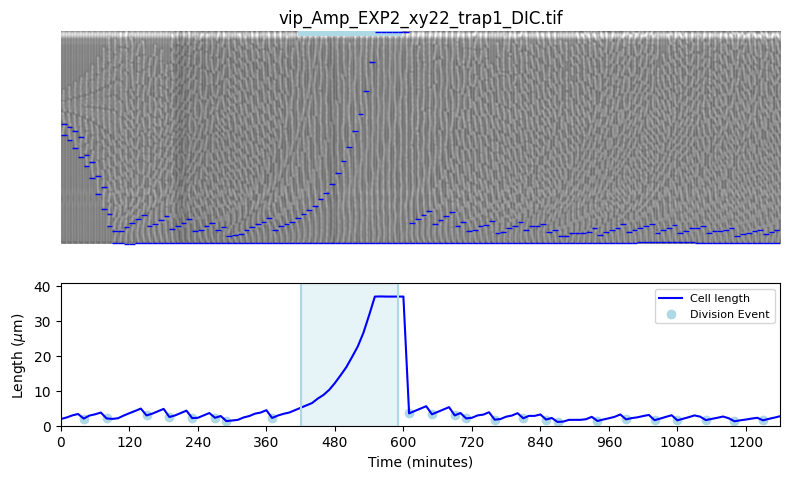

In [14]:

#files_to_plot = matched_files #All files
num_files_to_plot = len(files_to_plot)

# List to store PKL files with no division events
no_division_files = []

# Initialize global min and max frames
if num_files_to_plot>1:
    global_min_frame = float('inf')
    global_max_frame = float('-inf')

    # First pass: Find global min and max frames across all files
    for pkl_file, tif_file in files_to_plot:
        identifier = extract_file_identifier(pkl_file)
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)


        if time_series_data[0]:  # Only consider if there is data
            frames = time_series_data[0]  # Extract frames from time_series_data
            global_min_frame = 0  # min(global_min_frame, min(frames))
            global_max_frame = 2*630 #max(frames) #max(global_max_frame, max(frames))

global_min_frame= 0
global_max_frame = 2*630

# Second pass: Generate plots with global x-limits
for pkl_file, tif_file in files_to_plot:
    identifier = extract_file_identifier(pkl_file)
    time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)

    # Split the identifier
    parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
    replicate = parts[0]  # First element -> 'EXP1'
    position = parts[1]   # Second element -> 'xy04'
    trap = parts[2]       # Third element -> 'trap1'

    # Extract tini_amp, tend_amp, and tend from the DataFrame for this identifier
    filtered_df = df[(df['Replicate'] == replicate) &
                     (df['Position'] == position) &
                     (df['Trap'] == trap)]

    if not filtered_df.empty:
        tini_amp = float(filtered_df['tini_amp'].values[0])
        tend_amp = float(filtered_df['tend_amp'].values[0])
        tend = float(filtered_df['tend'].values[0])
    else:
        tini_amp, tend_amp, tend = None, None, None

    # Call analyze_division_events using metadata and Google Sheets data
    division_events = analyze_division_events(time_series_data, replicate, position, trap, df)

    # Check if there are no division events
    if not any(division_events[2]):
        no_division_files.append(pkl_file)


    this_breakpoints=get_breakpoints(all_data, identifier)

    #show_image_with_breakpoints(tif_file, this_breakpoints, x2frame)
    #plot_cell_lengths(time_series_data, division_events, tif_file, tini_amp, tend_amp, tend, global_min_frame, global_max_frame)

    plot_image_and_cell_lengths(
        tif_file,
        this_breakpoints,
        time_series_data,
        division_events,
        tini_amp,
        tend_amp,
        tend,
        global_min_frame,
        global_max_frame,
        channel_width=x2frame,
        base_path=base_path,
        image_path=tif_file
    )



In [15]:
#VIP205# Remove files with no division events from matched_files and all_data
no_division_files_removed = []  # List to store the files being removed

matched_files = [(pkl_file, tif_file) for pkl_file, tif_file in matched_files if pkl_file not in no_division_files or no_division_files_removed.append((pkl_file, tif_file))]

# Print the removed files
if no_division_files_removed:
    print("Removed the following files due to no division events:")
    for removed_file in no_division_files_removed:
        print(removed_file)
else:
    print("No files were removed.")

# Load each PKL file
all_data = {}
for pkl_file, tif_file in matched_files:
    data = load_pkl(pkl_file)
    all_data[pkl_file] = data


No files were removed.


In [16]:


# Modify the update_df_with_survival_status_and_plot function to keep track of survival frequency
def update_df_with_survival_status_and_plot(all_data, df, cell_type_filter=None):
    """Updates df with survival status based on whether a cell divided after tend_amp and generates plots."""
    # Ensure the DataFrame has the column `is_alive`
    if 'is_alive' not in df.columns:
        df['is_alive'] = None  # Initialize the column

    identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)

    # First pass: find global min and max frames
    global_min_frame = float('inf')
    global_max_frame = float('-inf')

    # First loop: determine global x-limits
    for identifier in identifiers:
        # Extract the correct position and trap from the identifier
        #position, trap = extract_position_and_trap(identifier)

        # Split the identifier
        parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
        replicate = parts[0]  # First element -> 'EXP1'
        position = parts[1]   # Second element -> 'xy04'
        trap = parts[2]       # Third element -> 'trap1'

        if position is None or trap is None:
            #print(f"Warning: Could not extract position or trap from identifier {identifier}, skipping...")
            continue

        # Analyze division events for this identifier
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:  # Only analyze if there is data
            # Retrieve tend_amp for this specific identifier
            filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
            if not filtered_df.empty:
                tend_amp = filtered_df['tend_amp'].values[0]
            else:
                #print(f"Warning: No tend_amp found for identifier {identifier}, skipping...")
                continue

            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, replicate, position, trap, df)

            # Update global min and max frames
            global_min_frame = min(global_min_frame, min(frames))
            global_max_frame = max(global_max_frame, max(frames))

    # Second pass: plot with the determined global x-limits
    total_cells_with_divisions = 0
    cells_with_divisions_after_tend_amp = 0
    survival_count = 0

    for identifier in identifiers:
        # Extract the correct position and trap from the identifier
        position, trap = extract_position_and_trap(identifier)

        if position is None or trap is None:
            print(f"Warning: Could not extract position or trap from identifier {identifier}, skipping...")
            continue

        # Filter based on cell type if specified
        if cell_type_filter is not None:
            cell_type = get_cell_type(df, position, trap)
            if cell_type_filter != cell_type:
                continue

        # Filter the DataFrame for the correct position and trap
        filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
        if filtered_df.empty:
            print(f"Warning: No data found for position {identifier}, skipping...")
            continue

        # Retrieve tend_amp for this specific identifier
        tend_amp = filtered_df['tend_amp'].values[0]
        tini_amp = filtered_df['tini_amp'].values[0]

        # Analyze division events for this identifier
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:  # Only analyze if there is data
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, tend_amp, replicate, position, trap, df)

            if any(cell_divisions):  # Check if there are any division events
                total_cells_with_divisions += 1
                if survived:
                    cells_with_divisions_after_tend_amp += 1

                # Update the 'is_alive' status in the DataFrame for this position and trap
                df.loc[(df['Position'] == position) & (df['Trap'] == trap), 'is_alive'] = survived

                # Keep track of survival count
                if survived:
                    survival_count += 1

            # Generate the plot with survival status and global x-limits
            global_min_frame=-40
            plot_cell_lengths(time_series_data, (frames, cell_lengths, cell_divisions, survived), identifier,
                              tini_amp=filtered_df['tini_amp'].values[0],
                              tend_amp=filtered_df['tend_amp'].values[0],
                              tend=filtered_df['tend'].values[0],
                              global_min_frame=global_min_frame, global_max_frame=global_max_frame)

    if total_cells_with_divisions == 0:
        freq_survival = 0.0  # Avoid division by zero
    else:
        freq_survival = survival_count / total_cells_with_divisions

    print(f"Survival frequency: {freq_survival}")
    return freq_survival, df  # Return the updated DataFrame as well


111


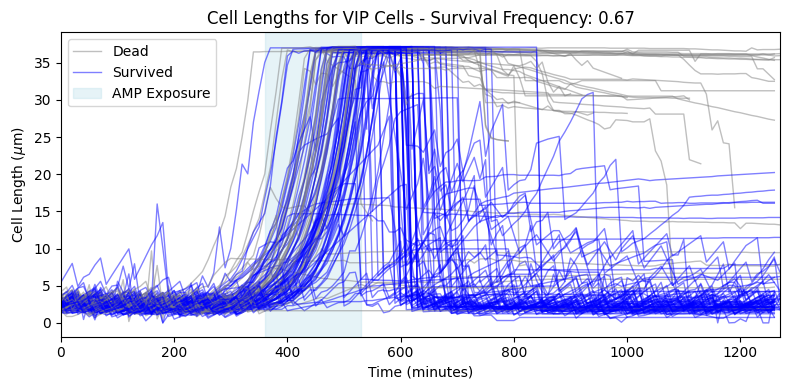

120


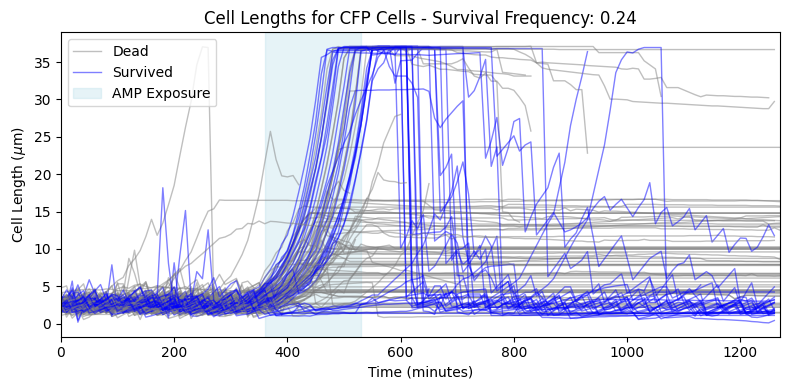

In [17]:
def plot_all_cells_in_single_plot(all_data, df, cell_type_filter=None, frames2min=10, pixel2um=1 / 22):
    """Plots cell lengths of all cells in a single plot with survival status, showing only 'Survived' and 'Dead' in the legend."""
    identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)

    # Initialize figure for plotting
    plt.figure(figsize=(8, 4))

    # Set global min and max frames for x-limits
    global_min_frame = float('inf')
    global_max_frame = float('-inf')

    # Initialize variables to track if we've added the Survived/Dead lines to the legend
    survived_plotted = False
    dead_plotted = False
    survived_count = 0
    total_cells = 0

    for identifier in identifiers:
        # Extract the correct position and trap from the identifier
        #position, trap = extract_position_and_trap(identifier)
        # Split the identifier
        parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
        replicate = parts[0]  # First element -> 'EXP1'
        position = parts[1]   # Second element -> 'xy04'
        trap = parts[2]       # Third element -> 'trap1'

        if position is None or trap is None:
            #print(f"Warning: Could not extract position or trap from identifier {identifier}, skipping...")
            continue

        # Filter based on cell type if specified
        if cell_type_filter is not None:
            cell_type = get_cell_type(df, position, trap)
            if cell_type_filter != cell_type:
                continue

        # Filter the DataFrame for the correct position and trap
        filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
        if filtered_df.empty:
            #print(f"Warning: No data found for position {position} and trap {trap}, skipping...")
            continue

        # Retrieve tend_amp for this specific identifier
        tend_amp = filtered_df['tend_amp'].values[0]

        # Analyze division events for this identifier
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:  # Only analyze if there is data
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, replicate, position, trap, df)

            total_cells += 1
            if survived:
                survived_count += 1

            # Set the survival status and line color based on survival
            line_color = 'blue' if survived else 'grey'
            label = None

            # Only add labels for "Survived" and "Dead" once
            if survived and not survived_plotted:
                label = "Survived"
                survived_plotted = True
            elif not survived and not dead_plotted:
                label = "Dead"
                dead_plotted = True

            # Shift frames by tini_amp and scale x and y data
            tini_amp = filtered_df['tini_amp'].values[0]
            scaled_x = (np.array(frames) ) * frames2min
            scaled_y = np.array(cell_lengths) * pixel2um

            global_min_frame = min(global_min_frame, min(scaled_x))
            global_max_frame = 2*635 #max(global_max_frame, max(scaled_x))

            # Plot the time series for this cell
            plt.plot(scaled_x, scaled_y, color=line_color, linewidth=1, alpha=0.5, label=label)

    # Calculate survival frequency
    if total_cells > 0:
        survival_freq = survived_count / total_cells
    else:
        survival_freq = 0.0

    print(total_cells)
    # Use the global x-limits for consistency
    plt.xlim([global_min_frame, global_max_frame])
    #xticks = np.arange(-240, 540 , 60)
    #plt.xticks(xticks)

    # Annotate the red box for amp exposure on the overall plot
    plt.axvspan(tini_amp* frames2min, (tend_amp ) * frames2min, color='#ADD8E6', alpha=0.3, label='AMP Exposure')

    # Add labels and legend
    plt.xlabel('Time (minutes)')
    plt.ylabel(r'Cell Length ($\mu$m)')
    plt.title(f'Cell Lengths for {cell_type_filter} Cells - Survival Frequency: {survival_freq:.2f}')



    # Only show "Survived" and "Dead" in the legend
    plt.legend(loc='upper left')

    # Display the plot
    plt.tight_layout()
    plt.show()

# Plot all VIP cells in a single plot
plot_all_cells_in_single_plot(all_data, df, cell_type_filter="VIP")

# Plot all CFP cells in a single plot
plot_all_cells_in_single_plot(all_data, df, cell_type_filter="CFP")


In [18]:
def plot_heatmap_with_divisions(division_events, identifiers, df, filter_type='', frames2min=10, pixel2um=0.11):
    survived_events = []
    non_survived_events = []

    # Debug: Check initial division event count
    print(f"Total division events received: {len(division_events)}")

    for identifier, event in zip(identifiers, division_events):
        frames, cell_lengths, cell_divisions, survived = event

        # Extract metadata from identifier
        parts = identifier.split('_')  # Format: 'EXP1_xy04_trap1'
        replicate = parts[0]  # 'EXP1'
        position = parts[1]   # 'xy04'
        trap = parts[2]       # 'trap1'

        # Look up tini_amp in df
        filtered_df = df[
            (df['Replicate'] == replicate) &
            (df['Position'] == position) &
            (df['Trap'] == trap)
        ]

        if not filtered_df.empty:
            tini_amp = float(filtered_df['tini_amp'].values[0])  # Extract tini_amp from df
        else:
            #print(f"Warning: No tini_amp found for {replicate}, {position}, {trap}. Skipping...")
            continue  # Skip this entry if tini_amp is missing

        # Use Google Sheets status
        if survived:
            survived_events.append((frames, cell_lengths, cell_divisions, survived, tini_amp))
        else:
            non_survived_events.append((frames, cell_lengths, cell_divisions, survived, tini_amp))

    sorted_division_events = survived_events + non_survived_events

    # Handle empty list gracefully
    if not sorted_division_events:
        #print("Warning: No valid division events found. Skipping heatmap generation.")
        return None

    num_cells = len(sorted_division_events)
    num_frames = max(len(frames) for frames, _, _, _, _ in sorted_division_events)

    heatmap_data = np.zeros((num_cells, num_frames))

    total_lengths = []
    total_divisions = []
    division_rates = []
    elongation_rates = []  # Store elongation rates
    time_between_divisions_all = []  # Store mean time between division events for each cell

    for i, (frames, cell_lengths, cell_divisions, survived, tini_amp) in enumerate(sorted_division_events):
        # Populate the heatmap with cell lengths, converting from pixels to micrometers
        for j, frame in enumerate(frames):
            if j < len(cell_lengths):
                heatmap_data[i, j] = cell_lengths[j] * pixel2um  # Cap cell lengths in \(\mu\)m

        # Collect data for statistics

        lengths_before_tini = [cell_lengths[j] * pixel2um for j, frame in enumerate(frames) if frame < tini_amp]
        divisions_before_tini = [cell_divisions[j] for j, frame in enumerate(frames) if frame < tini_amp]
        time_elapsed = max([frame for frame in frames if frame < tini_amp], default=0)

        total_lengths.extend(lengths_before_tini)
        total_divisions.extend(divisions_before_tini)


        if time_elapsed > 0:  # Avoid division by zero
            division_rate = sum(divisions_before_tini) / (time_elapsed * frames2min)
            division_rates.append(division_rate)

        # Compute elongation rate
        if len(frames) > 1:  # Ensure at least two time points
            time_intervals = np.diff(frames) * frames2min  # Convert frame differences to minutes
            length_intervals = np.diff([l * pixel2um for l in cell_lengths])  # Convert length differences to \(\mu\)m
            rates = length_intervals / time_intervals  # Compute elongation rates
            elongation_rates.extend(rates)

        # Compute mean time between division events for this cell
        division_frames = [frame for frame, div in zip(frames, cell_divisions) if div]
        if len(division_frames) > 1:  # At least two division events are needed
            time_intervals = np.diff(division_frames) * frames2min  # Convert to minutes
            mean_time_between_divisions = np.mean(time_intervals)
            time_between_divisions_all.append(mean_time_between_divisions)

    # Compute overall statistics
    mean_length = np.mean(total_lengths) if total_lengths else np.nan
    std_length = np.std(total_lengths) if total_lengths else np.nan

    mean_divisions = np.mean(total_divisions) if total_divisions else np.nan
    std_divisions = np.std(total_divisions) if total_divisions else np.nan

    mean_division_rate = np.mean(division_rates) if division_rates else np.nan
    std_division_rate = np.std(division_rates) if division_rates else np.nan

    mean_elongation_rate = np.mean(elongation_rates) if elongation_rates else np.nan
    std_elongation_rate = np.std(elongation_rates) if elongation_rates else np.nan

    mean_time_between_divisions_all = np.mean(time_between_divisions_all) if time_between_divisions_all else np.nan
    std_time_between_divisions_all = np.std(time_between_divisions_all) if time_between_divisions_all else np.nan

    # Statistics on survival
    num_survived = len(survived_events)
    num_non_survived = len(non_survived_events)
    survival_percentage = (num_survived / num_cells * 100) if num_cells > 0 else 0.0

    # Store statistics in a dictionary
    statistics = {
        "filter_type": filter_type or "All Cells",
        #"critical_timepoint_frames": critical_timepoint,
        #"critical_timepoint_minutes": critical_timepoint_minutes,
        "num_cells": num_cells,
        "num_survived": num_survived,
        "num_non_survived": num_non_survived,
        "survival_percentage": survival_percentage,
        "mean_cell_length": (mean_length, std_length, "μm"),
        "mean_divisions": (mean_divisions, std_divisions, "count"),
        "mean_division_rate": (mean_division_rate, std_division_rate, "divisions/min"),
        "mean_elongation_rate": (mean_elongation_rate, std_elongation_rate, "μm/min"),
        "mean_time_between_divisions": (mean_time_between_divisions_all, std_time_between_divisions_all, "minutes"),
    }

    # Print statistics
    print(f"Statistics for {filter_type or 'All Cells'}:")
    for key, value in statistics.items():
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

    # Plot the heatmap
    plt.figure(figsize=(8, 4))
    heatmap = sns.heatmap(heatmap_data, cmap='viridis', vmax=40, cbar_kws={'label': r'Cell Length ($\mu$m)'}, yticklabels=False, xticklabels=False)

    # Mark divisions with a black overlay dot on top of the heatmap
    for i, (frames, cell_lengths, cell_divisions, survived, tini_amp)  in enumerate(sorted_division_events):
        for j, frame in enumerate(frames):
            if j < len(cell_divisions) and cell_divisions[j]:
                plt.scatter(j + 0.5, i + 0.5, color='black', s=6)  # Mark division events


    plt.axhline(len(survived_events), color='white', linewidth=2)  # Horizontal line separating Alive/Dead

    plt.xlabel('Time (minutes)', fontsize=11)
    plt.title(filter_type or 'All Cells', fontsize=11)

    plt.tight_layout()
    plt.show()

    return statistics


Total division events received: 111
Statistics for VIP:
  filter_type: VIP
  num_cells: 110
  num_survived: 74
  num_non_survived: 36
  survival_percentage: 67.2727
  mean_cell_length: (np.float64(7.662832233741753), np.float64(5.683560390103417), 'μm')
  mean_divisions: (np.float64(0.17483506126295947), np.float64(0.37982596358876886), 'count')
  mean_division_rate: (np.float64(0.017246202128199682), np.float64(0.0044313356690434385), 'divisions/min')
  mean_elongation_rate: (np.float64(0.017451687293412253), np.float64(0.584626955797683), 'μm/min')
  mean_time_between_divisions: (np.float64(80.54703244560832), np.float64(44.003011658629745), 'minutes')


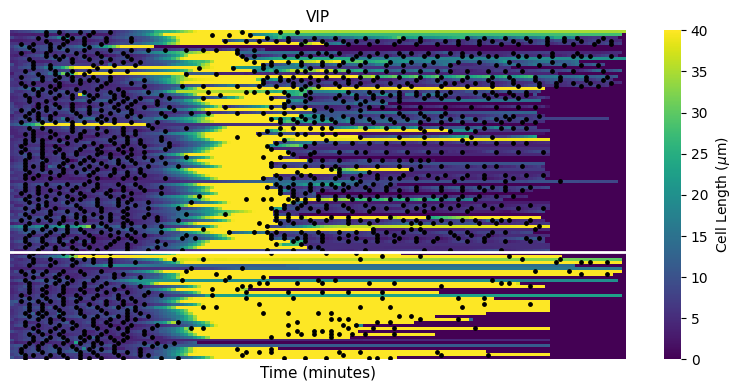

In [19]:
# Collect division events for the given cell type
cell_type_filter = "VIP"  # Specify the cell type you want to filter by

#this_tend_amp=60

identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)
division_events = []
time_between_divisions = []  # List to store mean time between division events for each cell

for identifier in identifiers:
    time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)

    # Extract the position and trap from the identifier
    parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
    replicate = parts[0]  # First element -> 'EXP1'
    position = parts[1]   # Second element -> 'xy04'
    trap = parts[2]       # Third element -> 'trap1'
    #position, trap = extract_position_and_trap(identifier)

    # Get the tend_amp value for this identifier
    filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
    if not filtered_df.empty:
        #tend_amp = filtered_df['tend_amp'].values[0]  # Get the tend_amp value
        #tend_amp=this_tend_amp

        if time_series_data[0]:  # Only analyze if there is data
            # Pass both time_series_data and tend_amp to analyze_division_events
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, replicate, position, trap, df)
            division_events.append((frames, cell_lengths, cell_divisions, survived))

            # Calculate time intervals between division events
            division_frames = [frame for frame, div in zip(frames, cell_divisions) if div]
            if len(division_frames) > 1:  # At least two division events are needed to compute intervals
                intervals = np.diff(division_frames)  # Time differences between consecutive division events
                mean_interval = np.mean(intervals)  # Average time between division events
                time_between_divisions.append(mean_interval)


# Plot the heatmap with division events
stats_VIP = plot_heatmap_with_divisions(division_events, identifiers, df, cell_type_filter)


Total division events received: 120
Statistics for CFP:
  filter_type: CFP
  num_cells: 119
  num_survived: 28
  num_non_survived: 91
  survival_percentage: 23.5294
  mean_cell_length: (np.float64(7.127785584768812), np.float64(4.840439991117258), 'μm')
  mean_divisions: (np.float64(0.19401631912964643), np.float64(0.3954415090010526), 'count')
  mean_division_rate: (np.float64(0.019493675518988084), np.float64(0.0047733577409318165), 'divisions/min')
  mean_elongation_rate: (np.float64(0.014908568519057318), np.float64(0.364300046177515), 'μm/min')
  mean_time_between_divisions: (np.float64(65.57502685747637), np.float64(26.44729388509487), 'minutes')


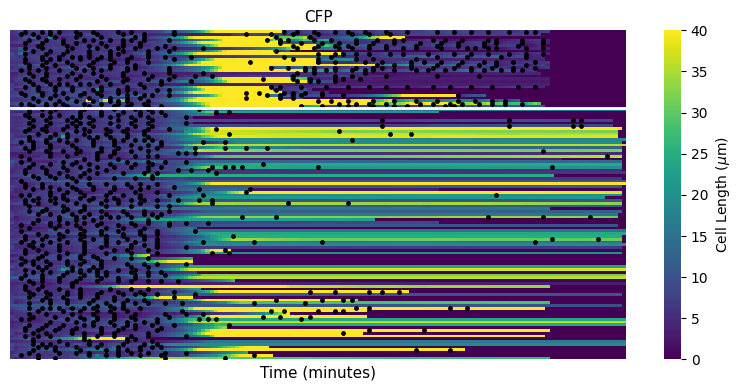

In [20]:
# Updated loop for collecting division events for the given cell type
cell_type_filter = "CFP"  # Specify the cell type you want to filter by

#this_tend_amp=60

identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)
division_events = []

for identifier in identifiers[1:]:
    # Get the time series data for the specific cell
    time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)

    # Retrieve the tend_amp value from the DataFrame
    #position, trap = extract_position_and_trap(identifier)
    parts = identifier.split('_')  # Expected format: 'EXP1_xy04_trap1'
    replicate = parts[0]  # First element -> 'EXP1'
    position = parts[1]   # Second element -> 'xy04'
    trap = parts[2]       # Third element -> 'trap1'
    filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]

    if filtered_df.empty:
        #print(f"Warning: No data found for position {position} and trap {trap}, skipping...")
        continue

    #tend_amp = filtered_df['tend_amp'].values[0]
    #tend_amp=this_tend_amp

    if time_series_data[0]:  # Only analyze if there is data
        division_events.append(analyze_division_events(time_series_data, replicate, position, trap, df))

# Plot the heatmap with division events
stats_CFP=plot_heatmap_with_divisions(division_events, identifiers, df, cell_type_filter)



In [21]:
print("VIP Stats:", stats_VIP)
print("CFP Stats:", stats_CFP)

import os
import pickle

def store_stats(stats_VIP, stats_CFP, data_path, expeID):
    """
    Stores the VIP and CFP statistics in a pickle file.

    Parameters:
    - stats_VIP: Dictionary of statistics for VIP cells.
    - stats_CFP: Dictionary of statistics for CFP cells.
    - data_path: Base directory where the file should be stored.
    - expeID: Experiment ID used to name the file.

    The output file will be stored as: data_path + expeID + '.pkl'
    """
    # Combine the statistics into a single dictionary
    combined_stats = {
        'stats_VIP': stats_VIP,
        'stats_CFP': stats_CFP
    }

    # Construct the full filename
    filename = os.path.join(data_path, expeID + '.pkl')

    # Save the dictionary to the pickle file
    with open(filename, 'wb') as f:
        pickle.dump(combined_stats, f)

    print(f"Stored statistics in {filename}")

store_stats(stats_VIP, stats_CFP, data_path, expeID)



VIP Stats: {'filter_type': 'VIP', 'num_cells': 110, 'num_survived': 74, 'num_non_survived': 36, 'survival_percentage': 67.27272727272727, 'mean_cell_length': (np.float64(7.662832233741753), np.float64(5.683560390103417), 'μm'), 'mean_divisions': (np.float64(0.17483506126295947), np.float64(0.37982596358876886), 'count'), 'mean_division_rate': (np.float64(0.017246202128199682), np.float64(0.0044313356690434385), 'divisions/min'), 'mean_elongation_rate': (np.float64(0.017451687293412253), np.float64(0.584626955797683), 'μm/min'), 'mean_time_between_divisions': (np.float64(80.54703244560832), np.float64(44.003011658629745), 'minutes')}
CFP Stats: {'filter_type': 'CFP', 'num_cells': 119, 'num_survived': 28, 'num_non_survived': 91, 'survival_percentage': 23.52941176470588, 'mean_cell_length': (np.float64(7.127785584768812), np.float64(4.840439991117258), 'μm'), 'mean_divisions': (np.float64(0.19401631912964643), np.float64(0.3954415090010526), 'count'), 'mean_division_rate': (np.float64(0.0

VIP (time=tini_amp)
Survived Lengths Range: Min=2.32, Max=37.18
Non-Survived Lengths Range: Min=1.64, Max=37.14
Mann-Whitney U Test:
Statistic: 1690.5
p-value: 0.04436893080075419
Survived Median: 36.86 μm
Non-Survived Median: 36.55 μm


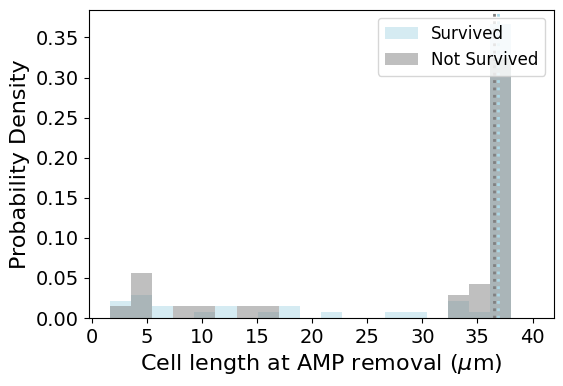

CFP (time=tini_amp)
Survived Lengths Range: Min=1.36, Max=37.09
Non-Survived Lengths Range: Min=1.41, Max=37.09
Mann-Whitney U Test:
Statistic: 1927.0
p-value: 0.00019805679118817243
Survived Median: 29.91 μm
Non-Survived Median: 9.73 μm


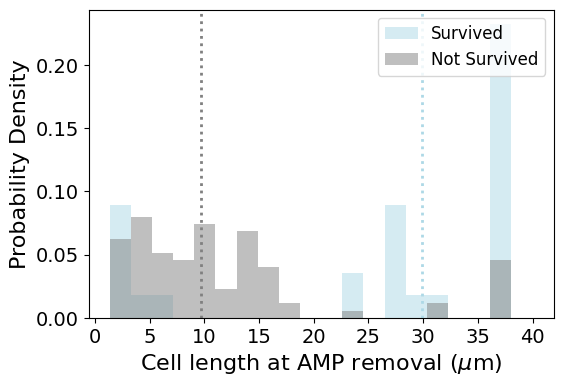

In [22]:


def plot_survival_vs_non_survival_distributions(all_data, df, cell_type_filter=None, pixel2um=1/22):
    identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)
    survived_lengths = []
    non_survived_lengths = []

    for identifier in identifiers:
        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:  # Only analyze if there is data

            # Parse identifier (Expected format: 'EXP1_xy04_trap1')
            parts = identifier.split('_')
            replicate = parts[0]  # 'EXP1'
            position = parts[1]   # 'xy04'
            trap = parts[2]       # 'trap1'

            # Retrieve tini_amp from df for this specific identifier
            filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
            if not filtered_df.empty:
                tini_amp = filtered_df['tini_amp'].values[0]
                tend_amp = filtered_df['tend_amp'].values[0]
            else:
                print(f"Warning: No tini_amp found for identifier {identifier}, skipping...")
                continue

            # Call analyze_division_events to get survived status from df
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(time_series_data, replicate, position, trap, df)

            # Get the cell length at tini_amp
            frames_array = np.array(frames)  # Convert list to NumPy array

            if len(frames_array) > 0:
                index = np.argmin(np.abs(frames_array - tend_amp))  # Get closest frame index
                length_at_tcrit = cell_lengths[index] * pixel2um  # Convert to micrometers

                if length_at_tcrit > 0:  # Filter out zero lengths
                    if survived:  # Use survived from analyze_division_events
                        survived_lengths.append(length_at_tcrit)
                    else:
                        non_survived_lengths.append(length_at_tcrit)

    # Print data range for debugging
    if survived_lengths and non_survived_lengths:
        print(f"Survived Lengths Range: Min={np.min(survived_lengths):.2f}, Max={np.max(survived_lengths):.2f}")
        print(f"Non-Survived Lengths Range: Min={np.min(non_survived_lengths):.2f}, Max={np.max(non_survived_lengths):.2f}")

    # Define dynamic bins based on data range
    all_lengths = survived_lengths + non_survived_lengths
    if all_lengths:
        min_length = np.min(all_lengths)
        max_length = 40 #np.max(all_lengths)
        num_bins = 20  # Define the desired number of bins
        bin_edges = np.linspace(min_length, max_length, num_bins + 1)
    else:
        print("No valid data to plot.")
        return

    # Perform the Mann-Whitney U test
    if survived_lengths and non_survived_lengths:
        stat, p_value = mannwhitneyu(survived_lengths, non_survived_lengths, alternative='two-sided')
        print(f'Mann-Whitney U Test:\nStatistic: {stat}\np-value: {p_value}')
    else:
        print('Not enough data for Mann-Whitney U Test.')

    # Plot the distributions
    plt.figure(figsize=(6, 4))

    if survived_lengths:
        plt.hist(survived_lengths, bins=bin_edges, alpha=0.5, density=True, label='Survived', color='#ADD8E6')
        survived_median = np.median(survived_lengths)
        plt.axvline(survived_median, color='#ADD8E6', linestyle='dotted', linewidth=2)
        print(f"Survived Median: {survived_median:.2f} μm")

    if non_survived_lengths:
        plt.hist(non_survived_lengths, bins=bin_edges, alpha=0.5, density=True, label='Not Survived', color='grey')
        non_survived_median = np.median(non_survived_lengths)
        plt.axvline(non_survived_median, color='grey', linestyle='dotted', linewidth=2)
        print(f"Non-Survived Median: {non_survived_median:.2f} μm")

    plt.xlabel(r'Cell length at AMP removal ($\mu$m)', fontsize=16)
    plt.ylabel('Probability Density', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

cell_type_filter = "VIP"  # Optionally specify the cell type
print(f"{cell_type_filter} (time=tini_amp)")
plot_survival_vs_non_survival_distributions(all_data, df, cell_type_filter)

cell_type_filter = "CFP"  # Optionally specify the cell type
print(f"{cell_type_filter} (time=tini_amp)")
plot_survival_vs_non_survival_distributions(all_data, df, cell_type_filter)


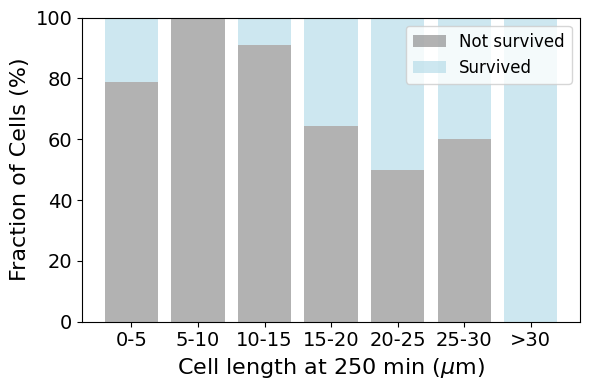

In [23]:

def plot_length_bin_survival_fraction(
    all_data, df, cell_type_filter=None, timepoint=250,
    frames2min=10, pixel2um=1/22
):
    """
    Plots stacked bar histogram of survival vs death for fixed cell length bins (0–40 μm, step 5),
    normalized so each bin sums to 100%, with labeled x-axis like `plot_binned_length_vs_survival_fraction`.
    """
    identifiers = get_identifiers_by_cell_type(all_data, df, cell_type_filter)
    bin_data = defaultdict(list)

    for identifier in identifiers:
        parts = identifier.split('_')
        replicate = parts[0]
        position = parts[1]
        trap = parts[2]

        if cell_type_filter:
            cell_type = get_cell_type(df, position, trap)
            if cell_type != cell_type_filter:
                continue

        filtered_df = df[(df['Position'] == position) & (df['Trap'] == trap)]
        if filtered_df.empty:
            continue

        time_series_data = get_time_series_of_cell_lengths(all_data, df, identifier)
        if time_series_data[0]:
            frames, cell_lengths, cell_divisions, survived = analyze_division_events(
                time_series_data, replicate, position, trap, df
            )
            scaled_x = np.array(frames) * frames2min
            scaled_y = np.array(cell_lengths) * pixel2um

            time_idx = np.argmin(np.abs(scaled_x - timepoint))
            if time_idx is not None:
                label = "Survived" if survived else "Dead"
                length = scaled_y[time_idx]
                bin_data[label].append(length)

    # Define fixed bins from 0 to 40 μm in steps of 5
    bins = np.arange(0, 40, 5)
    #bin_labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)]
    bin_labels = [f'{bins[i]}-{bins[i+1]}' if i < len(bins) - 2 else f'>{bins[i]}' for i in range(len(bins) - 1)]


    # Histogram counts
    survived_counts, _ = np.histogram(bin_data["Survived"], bins=bins)
    dead_counts, _ = np.histogram(bin_data["Dead"], bins=bins)
    total_counts = survived_counts + dead_counts

    # Avoid divide-by-zero
    total_safe = np.where(total_counts == 0, 1, total_counts)
    survived_pct = 100 * survived_counts / total_safe
    dead_pct = 100 * dead_counts / total_safe

    # Plot
    plt.figure(figsize=(6, 4))
    plt.bar(bin_labels, dead_pct, color='grey', label='Not survived', alpha=0.6)
    plt.bar(bin_labels, survived_pct, bottom=dead_pct, color='#ADD8E6', label='Survived', alpha=0.6)

    # Labels
    plt.xlabel(f'Cell length at {timepoint} min ($\mu$m)', fontsize=16)
    plt.ylabel('Fraction of Cells (%)', fontsize=16)
    plt.legend(loc='upper right', fontsize=12)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim([0, 100])
    plt.tight_layout()
    plt.show()


plot_length_bin_survival_fraction(
    all_data, df, cell_type_filter='CFP', timepoint=250,
    frames2min=5, pixel2um=1/22)